<style>
.retail-container{
    width:100%;
    max-width:1200px;
    margin:16px auto;
    padding: clamp(16px,2.5vw,34px);
    box-sizing:border-box;
    background: linear-gradient(135deg, #ffe8cc 0%, #ffdbafff 50%, #ffb574 100%);
    border: 2px solid #fb923c;
    border-radius: 18px; 
    font-family: 'Segoe UI', Roboto, sans-serif;
    color: #2b2b2b;
    box-shadow: 0 8px 24px rgba(251,146,60,0.18);
    line-height: 1.6em;
}

.retail-container hr{ border:1px solid rgba(196,84,12,0.15); margin:22px 0; }

.retail-header{
    text-align:center;
    margin-bottom:6px;
}

.retail-header h1{
    color:#b45309;
    font-size: clamp(1.4rem, 3.2vw, 2.2em);
    font-weight:700;
    margin:0 0 6px 0;
}

.retail-header h3{
    color:#7c2d12;
    margin:0;
    font-weight:500;
    font-size: clamp(0.95rem, 1.8vw, 1.1rem);
}

.retail-intro p{ font-size: clamp(0.98rem, 1.6vw, 1.08em); margin-bottom:10px; }

.retail-list{ font-size: clamp(0.95rem, 1.6vw, 1.05em); color:#3b2b20; margin-left:25px; margin-bottom:18px; }

.meta-cards{
    display:flex;
    justify-content:space-between;
    flex-wrap:wrap;
    gap:14px;
    margin:20px 0;
}

.meta-card{
    flex:1;
    min-width:220px;
    background:rgba(255,255,255,0.75);
    padding:14px 16px;
    border-radius:12px;
    border:1px solid rgba(250, 164, 76, 0.25);
    box-shadow: 0 2px 8px rgba(250,164,76,0.1);
}

.meta-card p{ margin:6px 0; font-size:0.99rem; color:#3b2b20; }

.section-title{
    color:#b45309;
    font-size: clamp(1rem, 1.8vw, 1.4em);
    margin-bottom:10px;
    text-transform:uppercase;
}

.objectives{ font-size: clamp(0.95rem, 1.6vw, 1.05em); color:#3b2b20; margin-left:25px; }

.note{
    margin-top:24px;
    margin-bottom:24px;
    padding:14px 6px 14px 16px;
    border-left:4px solid #fb923c;
    background:rgba(255,255,255,0.65);
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
}

@media (max-width:760px){
    .meta-cards{ flex-direction:column; }
    .meta-card{ max-width:90%; }
    .retail-container{ padding:16px; }
}
</style>

<div class="retail-container">

<div class="retail-header">
    <h1>🚦 EXPLORATION DES DONNÉES – US ACCIDENTS</h1>
    <h3><em>Projet NGO – Analyse statistique avancée des accidents de la route (2016 - 2023)</em></h3>
</div>

<hr>

<div class="retail-intro">
<h2 class="section-title">🎯 Objectifs de l'exploration</h2>

<ol class="objectives">
     <li><strong>Comprendre</strong> la structure, la granularité et la qualité du dataset US-Accidents</li>
    <li><strong>Identifier</strong> les valeurs manquantes, incohérences et outliers pouvant biaiser l’analyse</li>
    <li><strong>Explorer</strong> les patterns spatio-temporels (heures, jours, saisons, États)</li>
    <li><strong>Analyser</strong> l’impact de la météo, de l’infrastructure routière et du temps sur la gravité des accidents</li>
    <li><strong>Préparer</strong> les données pour des statistiques avancées, modélisation et reporting grand public</li>
</ol>
</div>

<div class="meta-cards">

  <div class="meta-card">
      <p><strong>📁 Dataset :</strong><br>
      <code style="background:rgba(255,249,240,0.8); color:#92400e; padding:3px 8px; border-radius:6px;">
        US_Accidents_(Sample_500k).csv
      </code></p>
      <p><strong>📊 Volume :</strong> ~7 000 000 accidents</p>
      <p><strong>🌍 Couverture :</strong> 49 États – États-Unis</p>
  </div>

  <div class="meta-card">
      <p><strong>🗓️ Période analysée :</strong><br> Février 2016 → Mars 2023</p>
      <p><strong>⏱️ Phase d’analyse :</strong> 05 → 16 janvier 2026</p>
      <p><strong>🎯 Finalité :</strong> Amélioration de la sécurité routière</p>
  </div>

  <div class="meta-card">
      <p>
        <strong>👥 Équipe :</strong><br>
        Asmae Janah<br>
        Zineb Ettahery<br>
        Hajar Mamdoug<br>
        Safia Daoudi
      </p>
  </div>

</div>

<hr>

<div class="note">
<strong>📌 Note méthodologique :</strong><br>
Cette phase d’exploration (EDA) constitue la base de toutes les analyses statistiques avancées
du projet. Les observations issues de cette étape guideront les choix de tests, modèles
(statistiques, GLM, séries temporelles, ACP) et permettront de produire un reporting clair,
fiable et compréhensible pour un public non technique.
</div>

</div>

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Importation des donnees</T1>

In [49]:
from tkinter import Tk, filedialog
import matplotlib.pyplot as plt
import dask.dataframe as dd
import seaborn as sns
import pandas as pd
import numpy as np
import polars as pl
import time
import os

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1>Chargement & Structure Initiale</T1>

In [50]:
# Masquer la fenêtre principale Tkinter
root = Tk()
root.withdraw()

# Forcer la fenêtre à être au premier plan
root.attributes('-topmost', True)
root.update()

# Ouvrir la fenêtre de sélection
fichier = filedialog.askopenfilename(
    title="Choisissez le fichier à analyser",
    filetypes=[("Fichiers CSV", "*.csv"), ("Fichiers Excel", "*.xlsx *.xls"), ("Tous les fichiers", "*.*")]
)

In [51]:
# Lecture du fichier sélectionné avec pandas
df = pd.read_csv(fichier)

MemoryError: Unable to allocate 1.15 GiB for an array with shape (20, 7728394) and data type object

In [6]:
# Faire une copie du DataFrame pandas
dfA = df.copy()

In [7]:
df.head(2000).to_csv("C:/Users/asmaj/Downloads/accidents.csv", index=False)

In [8]:
# Afficher les premières lignes du DataFrame
df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [9]:
# nombre de lignes et de colonnes
shape_data = dfa.shape
print(f'Le jeu de donnees contient {shape_data[0]} lignes et {shape_data[1]} colonnes.')

Le jeu de donnees contient 7728394 lignes et 46 colonnes.


In [10]:
# noms des colonnes
dfa.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='object')

In [11]:
# types de colonnes
dfa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7728394 entries, 0 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   ID                     object 
 1   Source                 object 
 2   Severity               int64  
 3   Start_Time             object 
 4   End_Time               object 
 5   Start_Lat              float64
 6   Start_Lng              float64
 7   End_Lat                float64
 8   End_Lng                float64
 9   Distance(mi)           float64
 10  Description            object 
 11  Street                 object 
 12  City                   object 
 13  County                 object 
 14  State                  object 
 15  Zipcode                object 
 16  Country                object 
 17  Timezone               object 
 18  Airport_Code           object 
 19  Weather_Timestamp      object 
 20  Temperature(F)         float64
 21  Wind_Chill(F)          float64
 22  Humidity(%)       

<style>
.retail-container{
    width:100%;
    max-width:1100px;
    margin:16px auto;
    padding: clamp(16px,2.5vw,34px);
    box-sizing:border-box;
    background: linear-gradient(135deg, #ffe8cc 0%, #ffdbaf 50%, #ffb574 100%);
    border: 2px solid #fb923c;
    border-radius: 18px; 
    font-family: 'Segoe UI', Roboto, sans-serif;
    color: #2b2b2b;
    box-shadow: 0 8px 24px rgba(251,146,60,0.18);
    line-height: 1.6em;
}

.retail-container hr{ border:1px solid rgba(196,84,12,0.15); margin:22px 0; }

.section-title{
    color:#b45309;
    font-size: clamp(1rem, 1.8vw, 1.4em);
    margin-bottom:10px;
    text-transform:uppercase;
}

.data-info, .column-table{
    font-size: clamp(0.95rem, 1.6vw, 1.05em);
    color:#3b2b20;
}

.data-info ul{
    list-style-type: "📊 ";
    padding-left:20px;
    margin-top:10px;
}

.column-table{
    width:100%;
    border-collapse: collapse;
    margin-top:16px;
}

.column-table th{
    background:#b45309;
    color:#fff;
    padding:10px;
    text-align:left;
    font-weight:600;
    border-radius:4px 4px 0 0;
}

.column-table td{
    background:rgba(255,255,255,0.85);
    padding:8px 10px;
    border-bottom:1px solid rgba(251,146,60,0.25);
}

.column-table tr:hover td{
    background:rgba(197, 93, 7, 0.81);
    color: #ffffff;
}

.alert{
    margin-top:18px;
    padding:14px 16px;
    background:rgba(255,249,240,0.9);
    border-left:4px solid #dc2626;
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
    box-shadow:0 2px 8px rgba(251,146,60,0.1);
}

code{
    background: #793b04ff;
    color:#fff;
    padding:2px 6px;
    border-radius:6px;
}

@media (max-width:760px){
    .column-table td, .column-table th{
        font-size:0.9em;
        padding:6px;
    }
}
</style>

<div class="retail-container">

<h2 class="section-title">🚦 Observations Initiales — Dataset Accidents Routiers</h2>

<div class="data-info">
<h3 style="color:#7c2d12;">Structure globale du dataset :</h3>
<ul>
    <li><strong>Nombre total de lignes :</strong> 7 728 394 accidents</li>
    <li><strong>Nombre total de colonnes :</strong> 46 variables</li>
    <li><strong>Nature des données :</strong> Spatio-temporelles, météorologiques et infrastructurelles</li>
</ul>
</div>

<hr>

<h3 style="color:#7c2d12;">Principales catégories de variables :</h3>

<table class="column-table">
    <thead>
        <tr>
            <th>Catégorie</th>
            <th>Colonnes concernées</th>
            <th>Description</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td>Identification</td>
            <td>ID, Source</td>
            <td>Identification unique et provenance des données</td>
        </tr>
        <tr>
            <td>Sévérité & Temps</td>
            <td>Severity, Start_Time, End_Time</td>
            <td>Niveau de gravité et temporalité de l’accident</td>
        </tr>
        <tr>
            <td>Localisation</td>
            <td>Start_Lat, Start_Lng, End_Lat, End_Lng</td>
            <td>Coordonnées géographiques précises</td>
        </tr>
        <tr>
            <td>Adresse</td>
            <td>Street, City, County, State, Zipcode</td>
            <td>Informations administratives et géographiques</td>
        </tr>
        <tr>
            <td>Météo</td>
            <td>Temperature, Humidity, Wind, Visibility, Weather_Condition</td>
            <td>Conditions climatiques au moment de l’accident</td>
        </tr>
        <tr>
            <td>Infrastructure</td>
            <td>Traffic_Signal, Junction, Crossing, Stop, Railway…</td>
            <td>Présence d’éléments routiers spécifiques</td>
        </tr>
        <tr>
            <td>Luminosité</td>
            <td>Sunrise_Sunset, Civil/Nautical/Astronomical_Twilight</td>
            <td>Conditions de lumière naturelle</td>
        </tr>
    </tbody>
</table>

<div class="alert">
⚠️ <strong>Points critiques détectés :</strong><br>
- Les colonnes <code>Start_Time</code>, <code>End_Time</code> et <code>Weather_Timestamp</code> sont en type <code>object</code> → conversion vers <code>datetime</code> indispensable.<br>
- Le volume du dataset (&gt; 7 millions de lignes) nécessite l’utilisation de <strong>Dask</strong> ou d’un échantillonnage pour l’EDA.<br>
- Plusieurs variables météorologiques contiennent des valeurs manquantes (<code>NaN</code>) → traitement requis avant modélisation.
</div>

</div>

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> Analyse de Qualité des Données</T1>

In [12]:
# valeurs manquantes par colonne
valeurs_nulles = dfa.isnull().sum()
taux_valeurs_nulles = round((df.isnull().sum() / len(dfa)) * 100, 2)

df_nulles = pd.DataFrame({
    'Colonne': valeurs_nulles.index,
    'Nb_Manquants': valeurs_nulles.values,
    'Pourcentage': taux_valeurs_nulles.values
}).sort_values('Nb_Manquants', ascending=False)

print(df_nulles[df_nulles['Nb_Manquants'] > 0])

                  Colonne  Nb_Manquants  Pourcentage
8                 End_Lng       3402762        44.03
7                 End_Lat       3402762        44.03
27      Precipitation(in)       2203586        28.51
21          Wind_Chill(F)       1999019        25.87
26        Wind_Speed(mph)        571233         7.39
24         Visibility(mi)        177098         2.29
25         Wind_Direction        175206         2.27
22            Humidity(%)        174144         2.25
28      Weather_Condition        173459         2.24
20         Temperature(F)        163853         2.12
23           Pressure(in)        140679         1.82
19      Weather_Timestamp        120228         1.56
42         Sunrise_Sunset         23246         0.30
43         Civil_Twilight         23246         0.30
45  Astronomical_Twilight         23246         0.30
44      Nautical_Twilight         23246         0.30
18           Airport_Code         22635         0.29
11                 Street         10869       

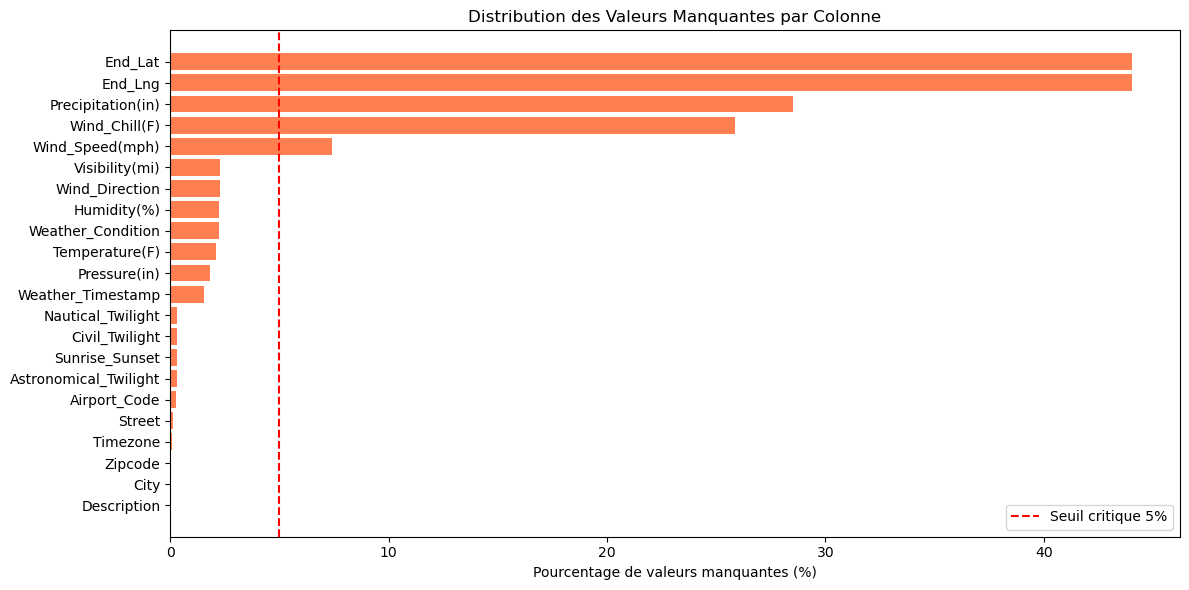

In [13]:
# Visualisation des valeurs manquantes
plt.figure(figsize=(12, 6))
df_nulles_plot = df_nulles[df_nulles['Nb_Manquants'] > 0].sort_values('Pourcentage')
plt.barh(df_nulles_plot['Colonne'], df_nulles_plot['Pourcentage'], color='coral')
plt.xlabel('Pourcentage de valeurs manquantes (%)')
plt.title('Distribution des Valeurs Manquantes par Colonne')
plt.axvline(x=5, color='red', linestyle='--', label='Seuil critique 5%')
plt.legend()
plt.tight_layout()
plt.show()

<style>
.retail-container{
    width:100%;
    max-width:1100px;
    margin:16px auto;
    padding: 30px;
    box-sizing:border-box;
    background: linear-gradient(135deg, #ffe8cc 0%, #ffdbafff 50%, #ffb574 100%);
    border: 2px solid #fb923c;
    border-radius: 18px; 
    font-family: 'Segoe UI', Roboto, sans-serif;
    color: #2b2b2b;
    box-shadow: 0 8px 24px rgba(251,146,60,0.18);
    line-height: 1.6em;
    padding-bottom: 30px !important;
}

.retail-container hr{ border:1px solid rgba(196,84,12,0.15); margin:22px 0; }

.section-title{
    color:#b45309;
    font-size: clamp(1rem, 1.8vw, 1.4em);
    margin-bottom:10px;
    text-transform:uppercase;
}

.subsection-title{
    color:#7c2d12;
    font-size: clamp(0.95rem, 1.6vw, 1.1em);
    margin:12px 0 4px 0;
    font-weight:600;
}

.retail-list, .detail-list{
    font-size: clamp(0.95rem, 1.6vw, 1.05em);
    color:#3b2b20;
    margin-left:25px;
    margin-bottom:18px;
}

.detail-list li{
    margin-bottom:6px;
}

.note{
    margin-top:16px;
    padding:12px 0px 12px 16px;
    border-left:4px solid #fb923c;
    background:rgba(255,255,255,0.65);
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
}

.alert{
    margin-top:18px;
    padding:14px 16px;
    background:rgba(255,249,240,0.9);
    border-left:4px solid #dc2626;
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
    box-shadow:0 2px 8px rgba(251,146,60,0.1);
}

code{
    background: #793b04ff;
    color:#fff;
    padding:2px 6px;
    border-radius:6px;
}

@media (max-width:760px){
    .retail-container{ padding:16px; }
}
</style>

<div class="retail-container">

<h2 class="section-title">📊 Analyse des Valeurs Manquantes — Dataset Accidents Routiers</h2>

<div class="alert">
🧠 <strong>Note méthodologique :</strong><br>
- Le <code>seuil critique</code> permet d’identifier les colonnes dont le taux de valeurs manquantes compromet la fiabilité analytique.<br>
- Cette analyse est essentielle compte tenu du volume élevé du dataset (<strong>7,7 millions de lignes</strong>).
</div>

<div class="alert">
💡 <strong>Règle de décision adoptée :</strong><br><br>

- <strong>&lt; 5 % de valeurs manquantes</strong><br>
👉 Impact faible → imputation simple possible (médiane / mode) ou suppression des lignes.<br><br>

- <strong>Entre 5 % et 20 %</strong><br>
👉 Analyse approfondie requise (origine des données, dépendance métier).<br><br>

- <strong>&gt; 20 %</strong><br>
👉 Colonne critique → suppression ou exclusion des analyses principales.
</div>

<hr>

<h3 class="subsection-title">🔴 Colonnes critiques (&gt; 20 % de valeurs manquantes)</h3>

<ul class="detail-list">
    <li><strong>End_Lat</strong> → 44.03 % (coordonnées de fin souvent absentes)</li>
    <li><strong>End_Lng</strong> → 44.03 %</li>
    <li><strong>Precipitation(in)</strong> → 28.51 %</li>
    <li><strong>Wind_Chill(F)</strong> → 25.87 %</li>
</ul>

<div class="note">
👉 Ces variables présentent un fort taux d’incomplétude et seront soit exclues, soit analysées séparément selon leur utilité métier.
</div>

<h3 class="subsection-title">🟠 Colonnes à surveiller (5 % – 10 %)</h3>

<ul class="detail-list">
    <li><strong>Wind_Speed(mph)</strong> → 7.39 %</li>
</ul>

<div class="note">
👉 Une imputation conditionnelle ou par segment temporel pourra être envisagée.
</div>

<h3 class="subsection-title">🟢 Colonnes faiblement impactées (&lt; 5 %)</h3>

<ul class="detail-list">
    <li>Visibility(mi) → 2.29 %</li>
    <li>Wind_Direction → 2.27 %</li>
    <li>Humidity(%) → 2.25 %</li>
    <li>Weather_Condition → 2.24 %</li>
    <li>Temperature(F) → 2.12 %</li>
    <li>Pressure(in) → 1.82 %</li>
    <li>Weather_Timestamp → 1.56 %</li>
    <li>Twilight variables (≈ 0.30 %)</li>
    <li>Airport_Code → 0.29 %</li>
    <li>Street, Timezone, Zipcode, City, Description → &lt; 0.2 %</li>
</ul>

<div class="note">
✅ Ces colonnes sont considérées comme fiables et peuvent être utilisées directement après un nettoyage léger.
</div>

</div>


In [14]:
# valeur dupliquées
nb_duplicats = df.duplicated().sum()
print(f'Nombre de lignes dupliquées : {nb_duplicats}')

Nombre de lignes dupliquées : 0


<style>
.retail-container{
    width:100%;
    max-width:1100px;
    margin:16px auto;
    padding: clamp(16px,2.5vw,34px);
    box-sizing:border-box;
    background: linear-gradient(135deg, #ffe8cc 0%, #ffdbafff 50%, #ffb574 100%);
    border: 2px solid #fb923c;
    border-radius: 18px; 
    font-family: 'Segoe UI', Roboto, sans-serif;
    color: #2b2b2b;
    box-shadow: 0 8px 24px rgba(251,146,60,0.18);
    line-height: 1.6em;
}

.retail-container hr{ border:1px solid rgba(196,84,12,0.15); margin:22px 0; }

.section-title{
    color:#b45309;
    font-size: clamp(1rem, 1.8vw, 1.4em);
    margin-bottom:10px;
    text-transform:uppercase;
}

.subsection-title{
    color:#7c2d12;
    font-size: clamp(0.95rem, 1.6vw, 1.1em);
    margin:12px 0 4px 0;
    font-weight:600;
}

.retail-list, .detail-list{
    font-size: clamp(0.95rem, 1.6vw, 1.05em);
    color:#3b2b20;
    margin-left:25px;
    margin-bottom:18px;
}

.detail-list li{
    margin-bottom:6px;
}

.note{
    margin-top:16px;
    padding:12px 16px;
    border-left:4px solid #fb923c;
    background:rgba(255,255,255,0.65);
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
}

.meta-cards{
    display:flex;
    justify-content:space-between;
    flex-wrap:wrap;
    gap:14px;
    margin:20px 0;
}

.meta-card{
    flex:1;
    position: relative;
    min-width:220px;
    background:rgba(255,255,255,0.75);
    padding:14px 16px;
    border-radius:12px;
    border:1px solid rgba(250, 164, 76, 0.25);
    box-shadow: 0 2px 8px rgba(250,164,76,0.1);
}

.alert{
    margin-top:18px;
    padding:14px 16px;
    background:rgba(255,249,240,0.9);
    border-left:4px solid #dc2626;
    border-radius:10px;
    font-size:0.97em;
    color:#5b341a;
    box-shadow:0 2px 8px rgba(251,146,60,0.1);
}

code{
    background: #793b04ff;
}

.meta-card p{ margin:6px 0; font-size:0.99rem; color:#3b2b20; }

@media (max-width:760px){
    .meta-cards{ flex-direction:column; }
    .meta-card{ max-width:90%; }
    .retail-container{ padding:16px; }
}
</style>

<div class="retail-container">

<h2 class="section-title">📊 Résultats : Valeurs dupliquee</h2>
<div class="alert">
Aucuns doublons dans la dataset 
</div>



</div>

<style>
T1 {
    display: inline-block;
    background: linear-gradient(90deg,#ffb457,#ff7043);
    color: #fff;
    padding: 10px 16px;
    border-radius: 8px;
    font-size: 25px;
    font-weight: 900;
    font-family: "Segoe UI", Roboto, Arial, sans-serif;
    box-shadow: 0 4px 10px rgba(0,0,0,0.12);
    letter-spacing: 0.2px;
    border: 1px solid rgba(255,255,255,0.15);
}
</style>

<T1> Analyse globale sur la distribustion</T1>

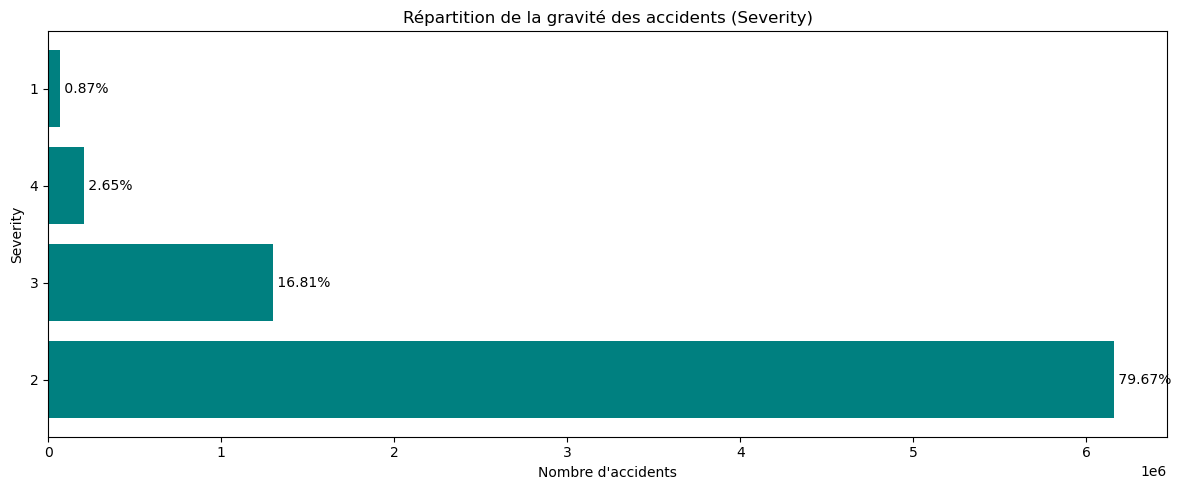

In [15]:
# ------------------------------------------------Severity Analysis

# Calcul unique
severity_counts = df["Severity"].value_counts(dropna=False)
severity_percent = round(severity_counts / severity_counts.sum() * 100, 2)

# DataFrame final
result = pd.DataFrame({
    'Severity': severity_counts.index,
    'Nombre': severity_counts.values,
    'Pourcentage (%)': severity_percent.values
})


# Affichage du résultat
plt.figure(figsize=(12, 5))
bars = plt.barh(
    result['Severity'].astype(str),
    result['Nombre'],
    color='teal'
)
plt.title("Répartition de la gravité des accidents (Severity)")
plt.xlabel("Nombre d'accidents")
plt.ylabel("Severity")

# Ajouter les pourcentages sur les barres
for bar, pct in zip(bars, result['Pourcentage (%)']):
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f' {pct}%',
        va='center'
    )

plt.tight_layout()
plt.show()

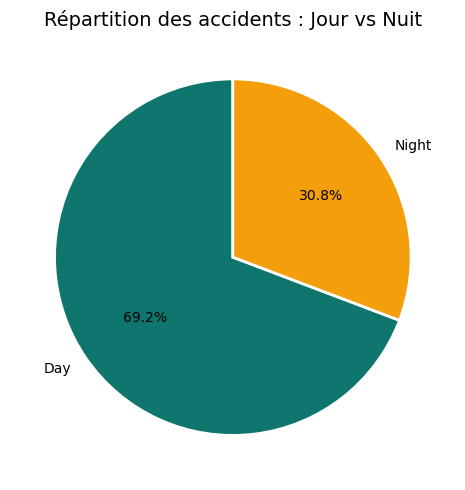

In [16]:
# ------------------------------------------------Day vs Night Analysis
plt.figure(figsize=(5, 5))

df['Sunrise_Sunset'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#0f766e', '#f59e0b'],  # Jour / Nuit (teal + amber)
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title("Répartition des accidents : Jour vs Nuit", fontsize=14)
plt.ylabel("")  # Supprimer le label automatique

plt.tight_layout()
plt.show()

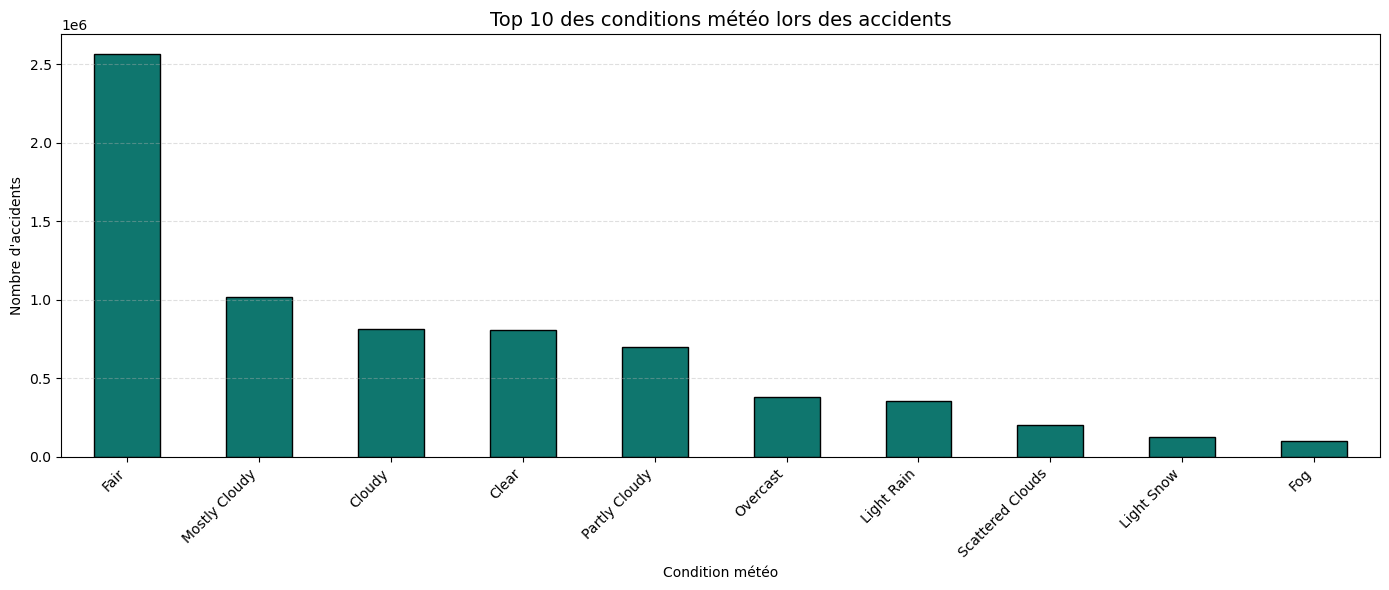

In [17]:
# ------------------------------------------------Weather Condition Analysis
plt.figure(figsize=(14, 6))

df['Weather_Condition'].value_counts().head(10).plot(
    kind='bar',
    color='#0f766e',  # teal
    edgecolor='black'
)

plt.title("Top 10 des conditions météo lors des accidents", fontsize=14)
plt.xlabel("Condition météo")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


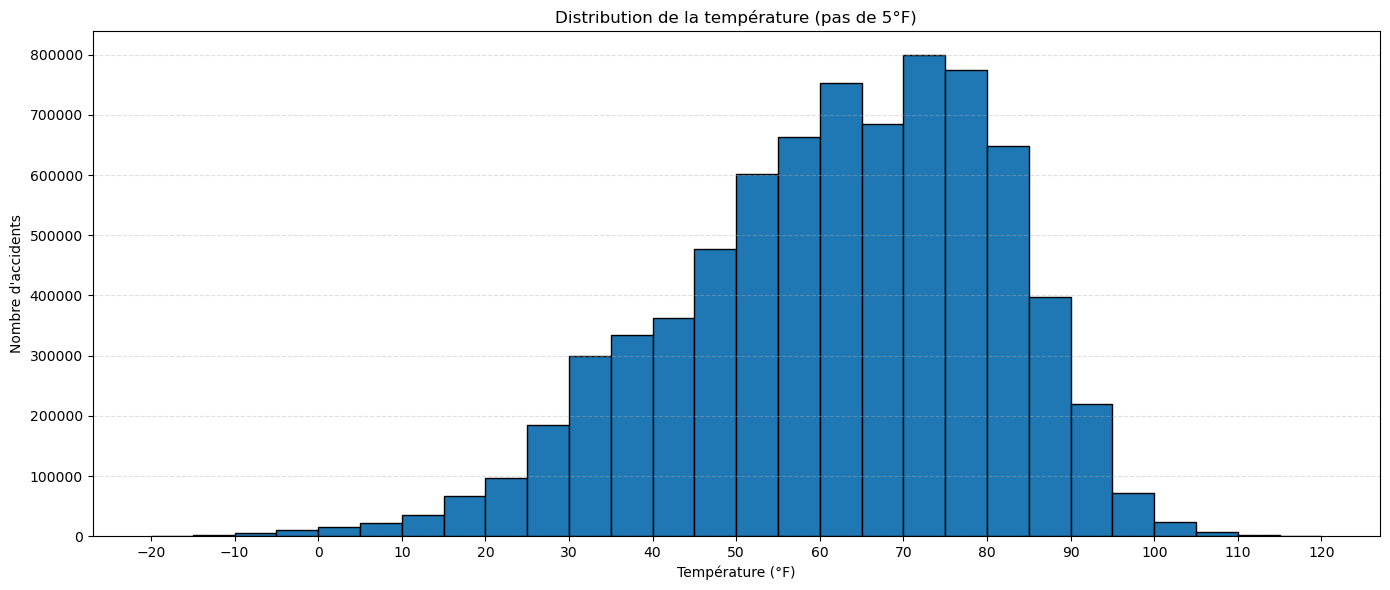

In [18]:
# -------------------------------------------------Temperature Analysis
bins = list(range(-20, 125, 5))  # tranche tous les 5°F

plt.figure(figsize=(14, 6))

df['Temperature(F)'].dropna().plot(
    kind='hist',
    bins=bins,
    edgecolor='black'
)

plt.xticks(bins[::2])  # affiche 1 tick sur 2 pour lisibilité

plt.title("Distribution de la température (pas de 5°F)")
plt.xlabel("Température (°F)")
plt.ylabel("Nombre d'accidents")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


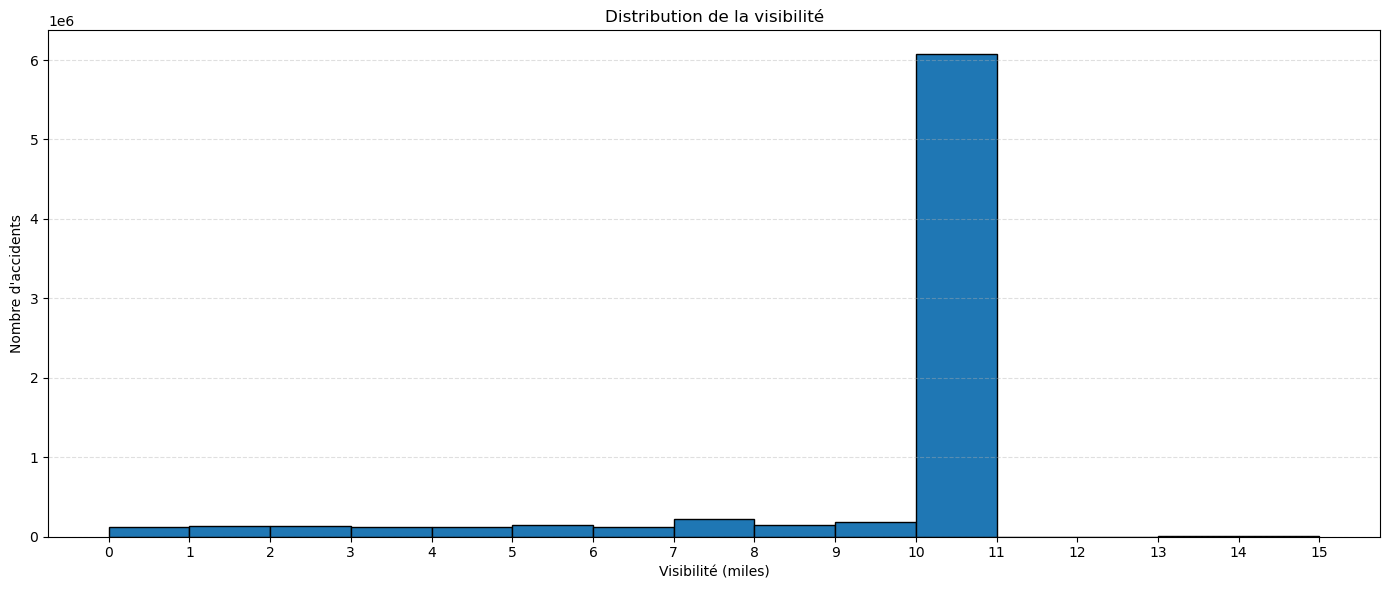

In [19]:
# -------------------------------------------------Visibility Analysis
plt.figure(figsize=(14, 6))

df['Visibility(mi)'].dropna().plot(
    kind='hist',
    bins=range(0, 16),  # visibilité de 0 à 15 miles
    edgecolor='black'
)

plt.title("Distribution de la visibilité")
plt.xlabel("Visibilité (miles)")
plt.ylabel("Nombre d'accidents")
plt.xticks(range(0, 16))
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


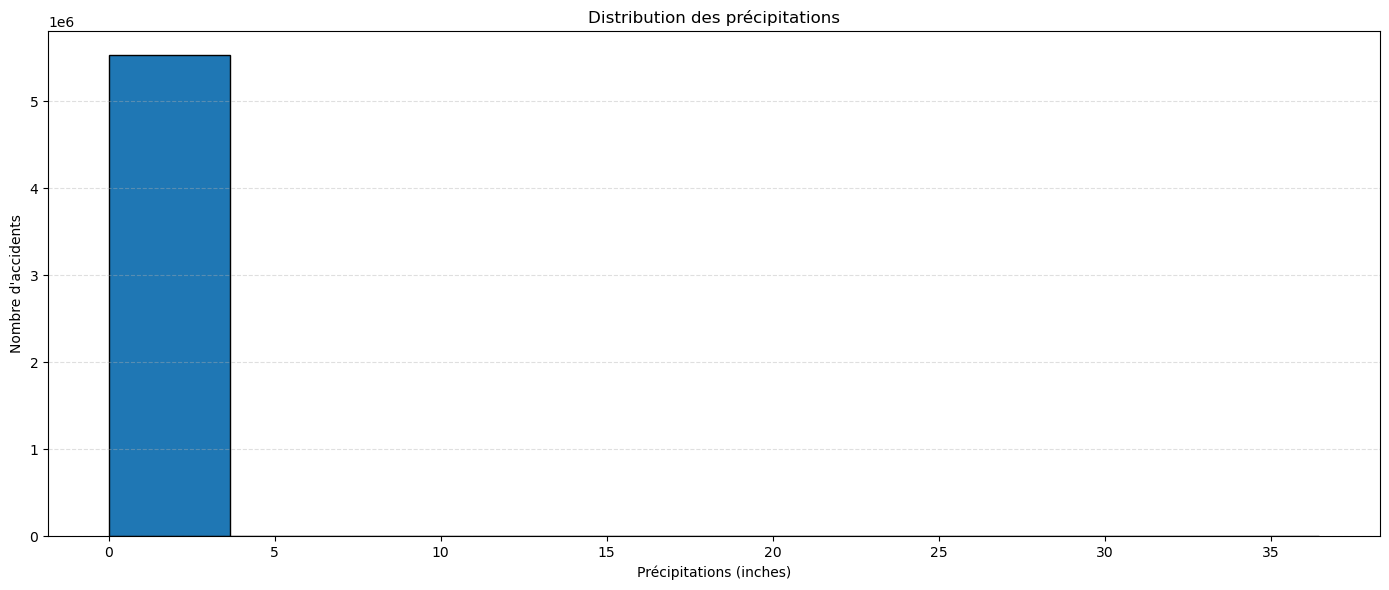

In [20]:
# -------------------------------------------------Precipitation Analysis

plt.figure(figsize=(14, 6))

df['Precipitation(in)'].dropna().plot(
    kind='hist',
    bins=10,
    edgecolor='black'
)

plt.title("Distribution des précipitations")
plt.xlabel("Précipitations (inches)")
plt.ylabel("Nombre d'accidents")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

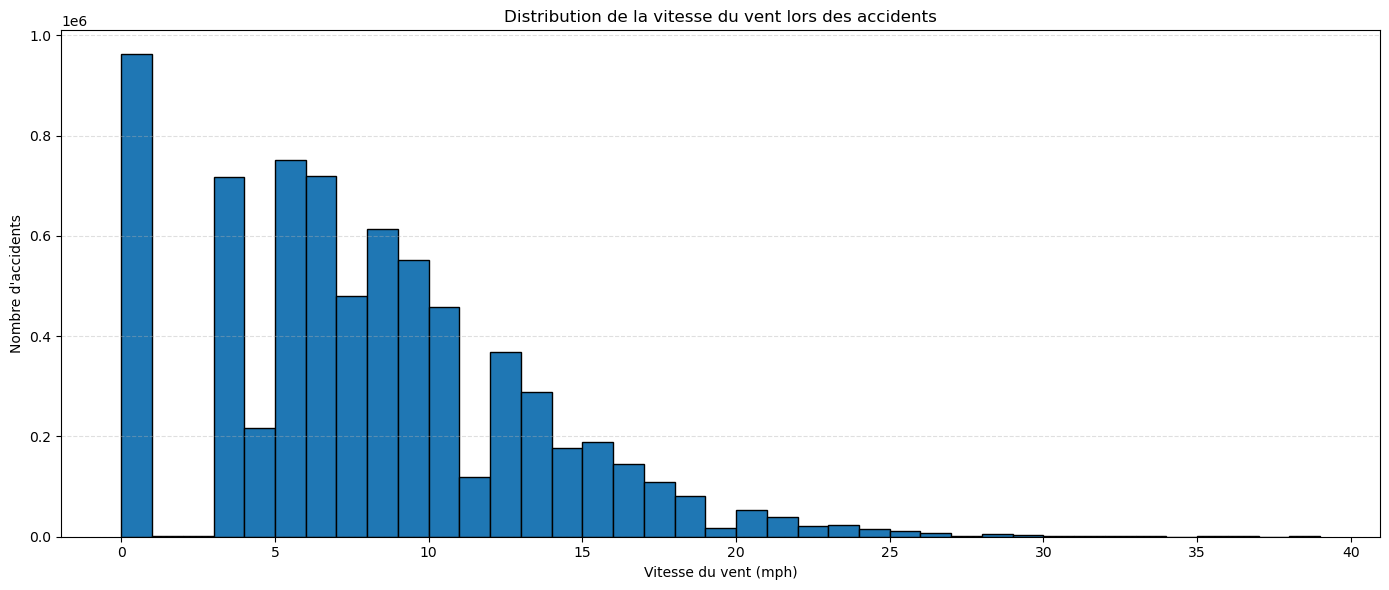

In [22]:
# -------------------------------------------------Wind_speed Analysis

plt.figure(figsize=(14, 6))

df['Wind_Speed(mph)'].dropna().plot(
    kind='hist',
    bins=range(0, 40),
    edgecolor='black'
)

plt.title("Distribution de la vitesse du vent lors des accidents")
plt.xlabel("Vitesse du vent (mph)")
plt.ylabel("Nombre d'accidents")

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

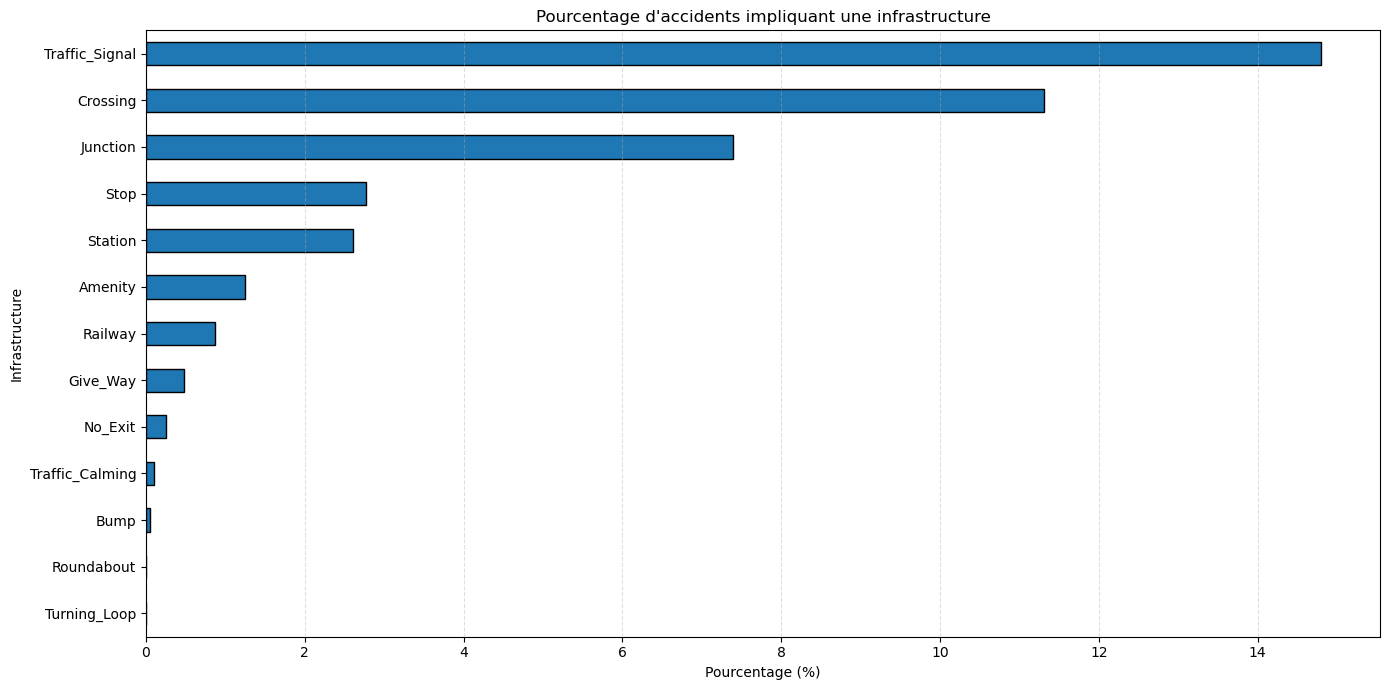

In [29]:
# ------------------------------------------------- Infrastructure Analysis

infra_cols = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
]

infra_percent = (df[infra_cols].sum() / len(df) * 100).sort_values()

plt.figure(figsize=(14, 7))
infra_percent.plot(
    kind='barh',
    edgecolor='black'
)

plt.title("Pourcentage d'accidents impliquant une infrastructure")
plt.xlabel("Pourcentage (%)")
plt.ylabel("Infrastructure")

plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [48]:
# Comptage des valeurs NaT avant conversion
print("Valeurs NaT avant conversion :")
print(f"Start_Time: {dfA['Start_Time'].isna().sum()}")
print(f"End_Time: {dfA['End_Time'].isna().sum()}")
print(f"Weather_Timestamp: {dfA['Weather_Timestamp'].isna().sum()}")

Valeurs NaT avant conversion :


NameError: name 'dfA' is not defined

In [ ]:
# Format mixed (le plus courant dans ce type de dataset)
dfA['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
dfA['End_Time'] = pd.to_datetime(df['End_Time'], format='mixed')
dfA['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], format='mixed')

In [ ]:
# Comptage des valeurs NaT après conversion
print("Valeurs NaT après conversion :")
print(f"Start_Time: {dfA['Start_Time'].isna().sum()}")
print(f"End_Time: {dfA['End_Time'].isna().sum()}")
print(f"Weather_Timestamp: {dfA['Weather_Timestamp'].isna().sum()}")

In [ ]:
# transformation de start_time en variables analytiques

# 1. year
dfA['year'] = dfA['Start_Time'].dt.year

# 2. month
dfA['month'] = dfA['Start_Time'].dt.month

# 3. time
dfA['time'] = dfA['Start_Time'].dt.strftime('%H:%M:%S')

# 4. Day of week
dfA["day_of_week"] = dfA["Start_Time"].dt.day_name()

# 5. Is Weekend (1 if Saturday/Sunday, 0 otherwise)
dfA['is_weekend'] = dfA['Start_Time'].dt.dayofweek.isin([5, 6]).astype(int)

# 6. Season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

dfA['season'] = dfA['month'].apply(get_season)

# 7. Period of the Day
def get_day_period(hour):
    if 5 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 17:
        return 'Afternoon'
    elif 17 <= hour < 21:
        return 'Evening'
    else:
        return 'Night'

dfA['day_period'] = dfA['Start_Time'].dt.hour.apply(get_day_period)


NameError: name 'dfA' is not defined

In [ ]:
dfA[['Start_Time', 'year', 'month', 'day_of_week', 'time','season','day_period','is_weekend']].head()